In [17]:
experiment = r".\results\figure2_wager_nx500\seed42_nB1000_new_x_dict_items([('max_leaf_nodes', 5)])"

import pandas as pd
import numpy as np
from utils import save_results_png, step_function
import matplotlib.pyplot as plt

df_preds = pd.read_csv(experiment + str("bagged_preds.csv"), sep=";")
df_vars_bias_correction = pd.read_csv(experiment + str("bias_correction.csv"), sep=";")
df_est_vars_biased = pd.read_csv(experiment + str("est_vars_biased.csv"), sep=";")
new_data_str = df_preds.columns[1:].to_list()
new_data = [float(i) for i in new_data_str]
new_data = np.array(new_data)

bagged_preds = df_preds[new_data_str]
est_vars_biased = df_est_vars_biased[new_data_str]
est_vars_bias_correction = df_vars_bias_correction[new_data_str]
est_vars_unbiased = est_vars_biased - est_vars_bias_correction

In [ ]:
save_results_png(
    new_data=new_data,
    bagged_preds=bagged_preds,
    est_vars_biased=est_vars_biased,
    bias_correction=est_vars_bias_correction,
    show_only_plot=True,
)

In [54]:
neg_vars = est_vars_unbiased[est_vars_unbiased < 0]

# entferne zeilen und spalten, wo alle werte NaN sind
neg_vars = neg_vars.dropna(axis=0, how="all")
neg_vars = neg_vars.dropna(axis=1, how="all")
x = neg_vars.columns.to_numpy()
x = [float(x) for x in x]

print("x_points with neg var_est: ", x)

x_points with neg var_est:  [0.34669338677354705]


x =  0.34669338677354705


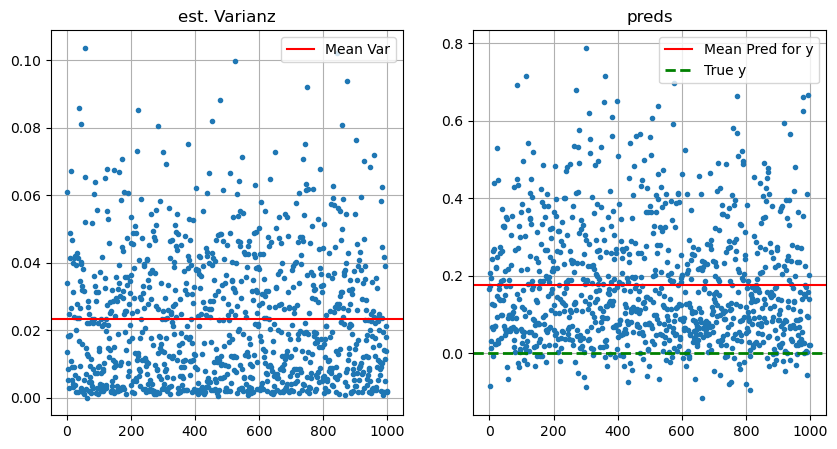

In [55]:
def plot_diagnostic(x):

    ind = (np.abs(new_data - x)).argmin()
    x = new_data[ind]
    y_true = step_function(x)
    print("x = ", x)

    vars = est_vars_unbiased.iloc[:, ind]
    preds = bagged_preds.iloc[:, ind]

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # Plot estimated variance
    axs[0].plot(vars, "o", markersize=3)
    mean_vars = np.mean(vars)
    axs[0].axhline(y=mean_vars, color="r", linestyle="-", label="Mean Var")
    axs[0].grid()
    axs[0].set_title("est. Varianz")
    axs[0].legend()

    # Plot predictions
    axs[1].plot(preds, "o", markersize=3)
    mean_preds = np.mean(preds)
    true_y = step_function(x)
    axs[1].axhline(y=mean_preds, color="r", linestyle="-", label="Mean Pred for y")
    axs[1].axhline(y=true_y, color="g", linestyle="--", label="True y", lw=2)
    axs[1].grid()
    axs[1].set_title("preds")
    axs[1].legend()

    plt.show()


plot_diagnostic(x)